In [1]:
import pandas as pd
import random
import numpy as np

In [2]:
l = []

for i in range(10000):
    l.append(random.randint(1,6))

In [3]:
l[:5]

[3, 3, 4, 5, 1]

In [4]:
s = (pd.Series(l).value_counts() / pd.Series(l).value_counts().sum()).sort_index()

In [5]:
s

1    0.1675
2    0.1703
3    0.1678
4    0.1680
5    0.1647
6    0.1617
Name: count, dtype: float64

<Axes: >

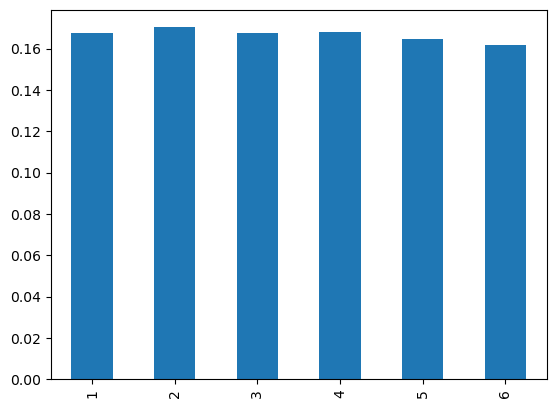

In [6]:
s.plot(kind = 'bar')

In [7]:
m = []

for i in range(10000):
    a = random.randint(1,6)
    b = random.randint(1,6)
    m.append(a + b)

In [8]:
s = (pd.Series(m).value_counts() / pd.Series(m).value_counts().sum()).sort_index()

In [9]:
s

2     0.0294
3     0.0553
4     0.0798
5     0.1112
6     0.1387
7     0.1624
8     0.1374
9     0.1129
10    0.0857
11    0.0569
12    0.0303
Name: count, dtype: float64

<Axes: >

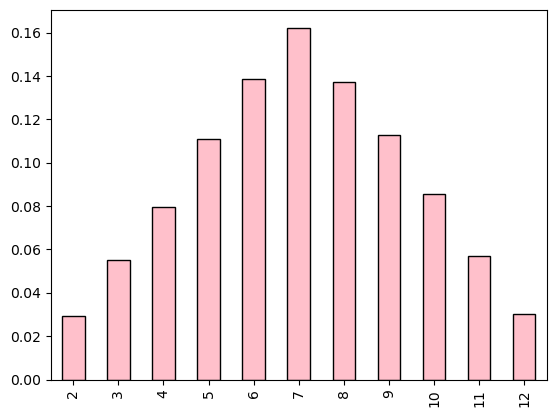

In [10]:
s.plot(kind = 'bar', color = 'pink', edgecolor = 'black',align='center')

<Axes: >

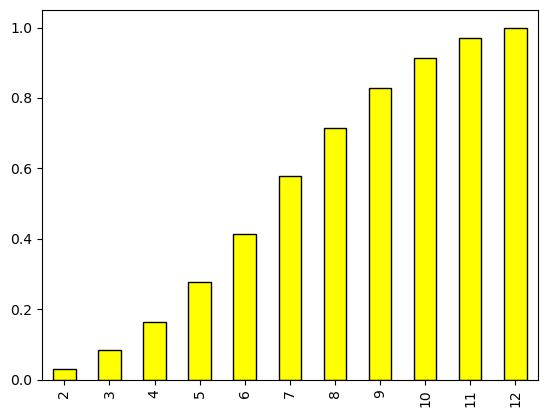

In [11]:
np.cumsum(s).plot(kind = 'bar', edgecolor = 'black',color = 'yellow')

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.random import normal

In [13]:
sample = normal(loc = 50, scale = 5, size = 1000)

In [14]:
sample_mean = sample.mean()
sample_std = sample.std()

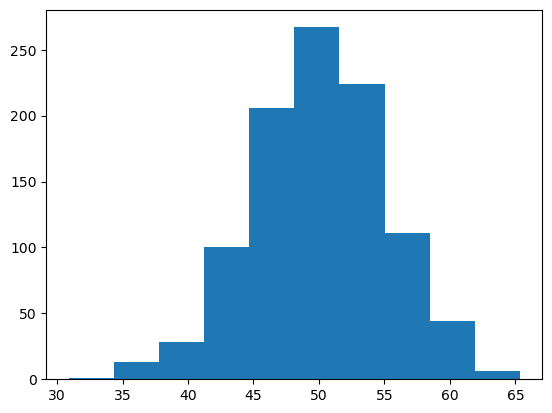

In [15]:
plt.hist(sample)
plt.show()

In [16]:
from scipy.stats import norm
dist = norm(sample_mean, sample_std)

In [17]:
values = np.linspace(sample.min(), sample.max(), 100)

In [18]:
probabilities = [dist.pdf(value) for value in  values]

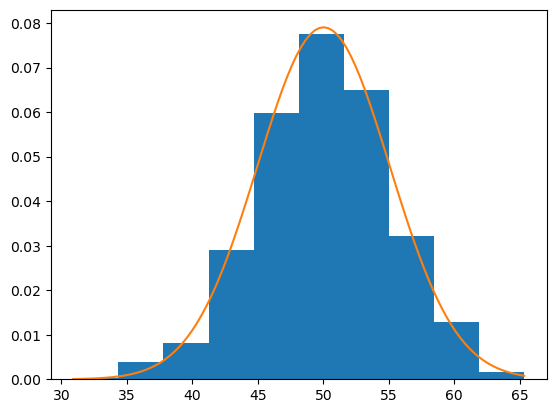

In [19]:
plt.hist(sample,bins = 10, density = True)
plt.plot(values,  probabilities)

/tmp/ipykernel_91522/1950040031.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

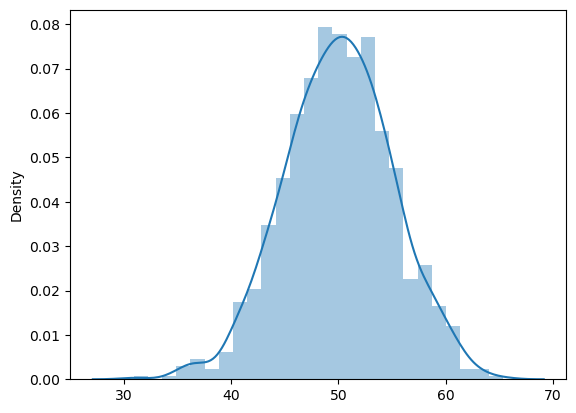

In [20]:
sns.distplot(sample)

In [21]:
sample1 = normal(loc = 20, scale = 5, size = 300)
sample2 = normal(loc = 40, scale = 5, size = 700)
sample = np.hstack((sample1, sample2)) # should pass tuple

(array([  2.,   5.,  15.,  21.,  34.,  33.,  67.,  52.,  41.,  19.,  25.,
         26.,  53.,  80.,  98., 112., 104.,  77.,  57.,  43.,  16.,  14.,
          3.,   1.,   2.]),
 array([ 7.23301621,  9.2761125 , 11.3192088 , 13.36230509, 15.40540139,
        17.44849768, 19.49159397, 21.53469027, 23.57778656, 25.62088286,
        27.66397915, 29.70707544, 31.75017174, 33.79326803, 35.83636433,
        37.87946062, 39.92255691, 41.96565321, 44.0087495 , 46.0518458 ,
        48.09494209, 50.13803838, 52.18113468, 54.22423097, 56.26732727,
        58.31042356]),
 <BarContainer object of 25 artists>)

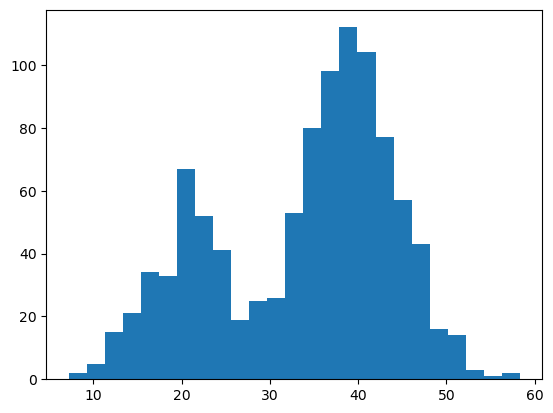

In [22]:
plt.hist(sample, bins = 25)

In [23]:
from sklearn.neighbors import KernelDensity
model = KernelDensity(bandwidth = 3, kernel = 'epanechnikov')

sample = sample.reshape((len(sample), 1))
model.fit(sample)

KernelDensity(bandwidth=3, kernel='epanechnikov')

In [24]:
values = np.linspace(sample.min(), sample.max(), 100)
values = values.reshape(len(values),1)

In [25]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

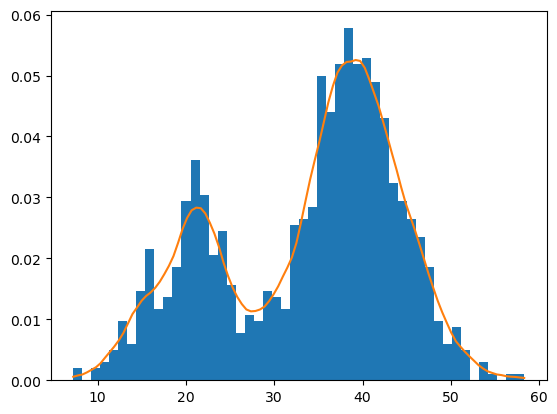

In [26]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

In [27]:
iris = sns.load_dataset('iris')

In [28]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

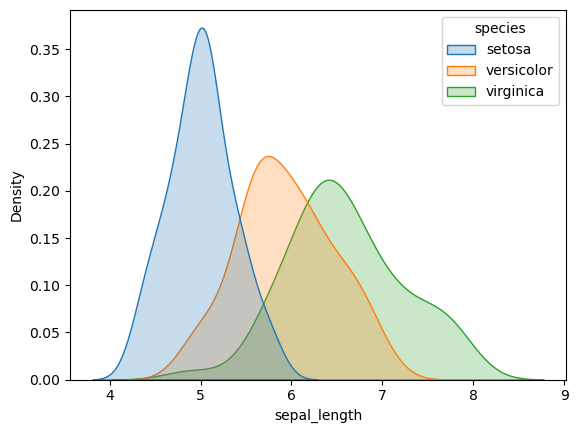

In [29]:
sns.kdeplot(data = iris, x = 'sepal_length', hue = 'species', fill = True)

<Axes: xlabel='sepal_width', ylabel='Density'>

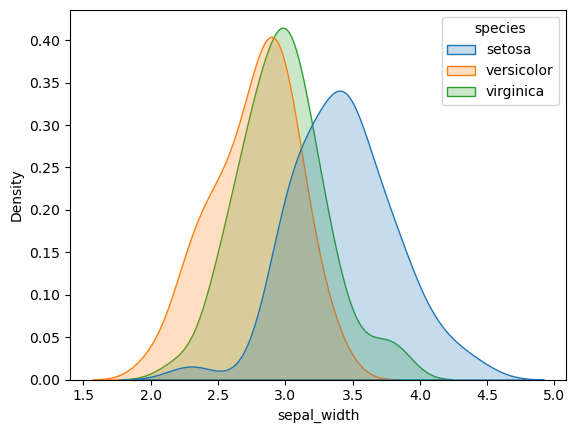

In [30]:
sns.kdeplot(data = iris, x = 'sepal_width', hue = 'species', fill = True)

'\n* if pe < 2.3 => setosa\n* if pe > 2.3 and pe < 5(intersection) => versicolor\n* if pe > 5  => verginica\n'

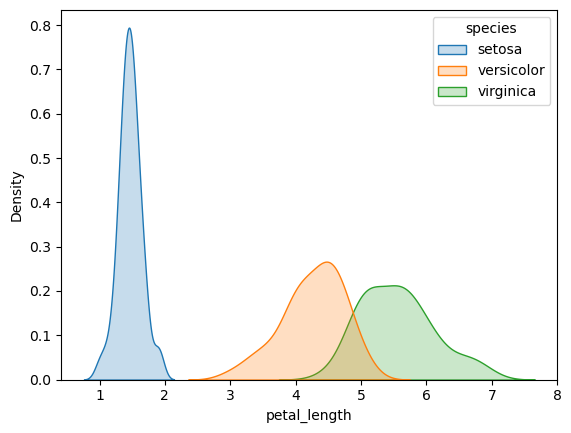

In [31]:
sns.kdeplot(data = iris, x = 'petal_length', hue = 'species', fill = True)

"""
* if pe < 2.3 => setosa
* if pe > 2.3 and pe < 5(intersection) => versicolor
* if pe > 5  => verginica
"""

'\n* if pe < 0.8 => setosa\n* if pe > 0.8 and pe < 1.8(intersection) => versicolor\n* if pe > 1.8  => verginica\n'

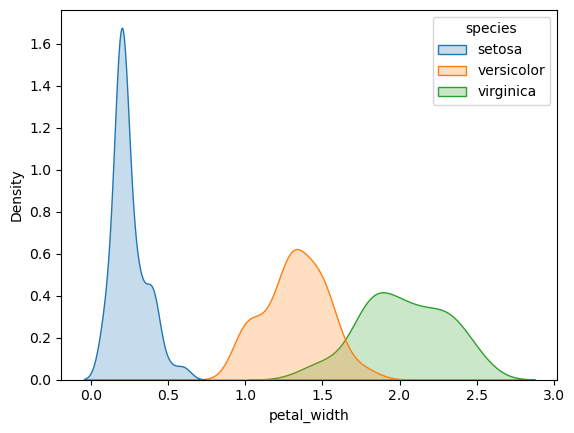

In [32]:
sns.kdeplot(data = iris, x = 'petal_width', hue = 'species', fill = True)

"""
* if pe < 0.8 => setosa
* if pe > 0.8 and pe < 1.8(intersection) => versicolor
* if pe > 1.8  => verginica
"""

In [33]:
titanic = sns.load_dataset('titanic')

In [34]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='age', ylabel='Density'>

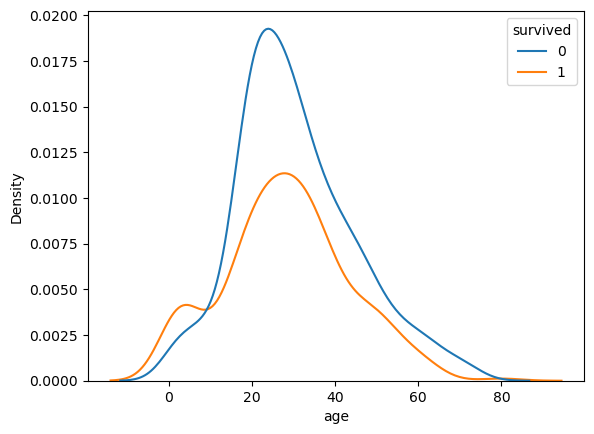

In [35]:
sns.kdeplot(data = titanic, x = 'age', hue = 'survived')
# probability of children  surviving is more than adults and elders

<Axes: xlabel='petal_width', ylabel='Density'>

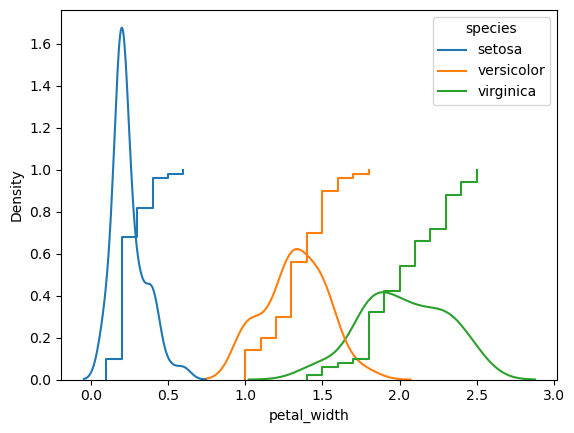

In [36]:
sns.kdeplot(data = iris, x = 'petal_width', hue = 'species')
sns.ecdfplot(data = iris, x = 'petal_width', hue = 'species')
# 0.7 < pw < 1.7 => 95% values and pw > 1.7 => 90% values

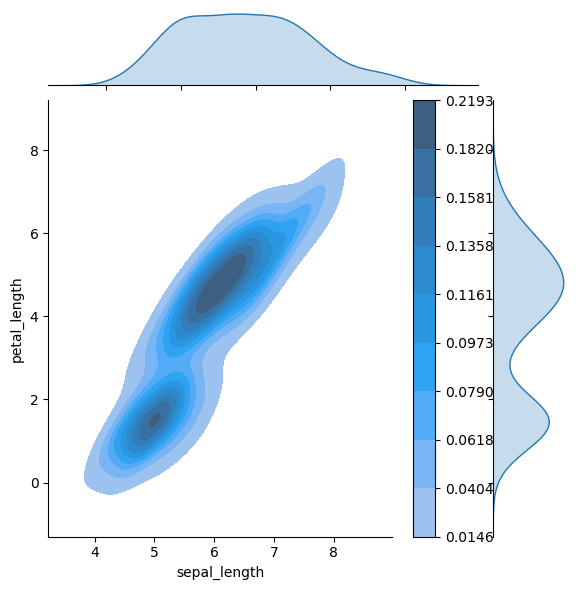

In [37]:
sns.jointplot(data =iris, x = 'sepal_length', y = 'petal_length', kind="kde",fill=True,cbar=True)
# dark color represents the high probability density distribution

In [38]:
titanic['age'].mean()

29.69911764705882

In [39]:
titanic['age'].std()

14.526497332334044

In [40]:
z = (titanic['age'] - titanic['age'].mean()) / titanic['age'].std()

<Axes: xlabel='age', ylabel='Density'>

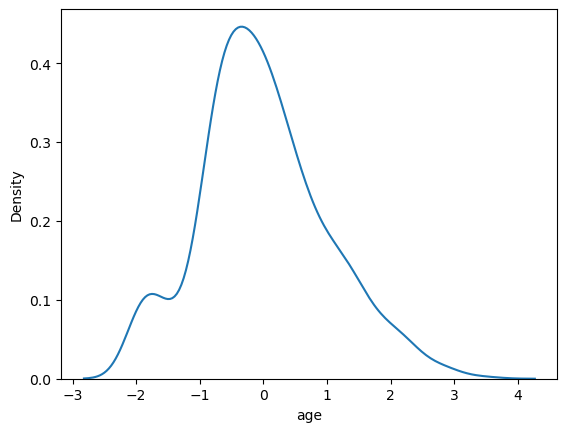

In [41]:
sns.kdeplot(z)
#mean is around 0 and std is 1

<Axes: xlabel='sepal_length', ylabel='Density'>

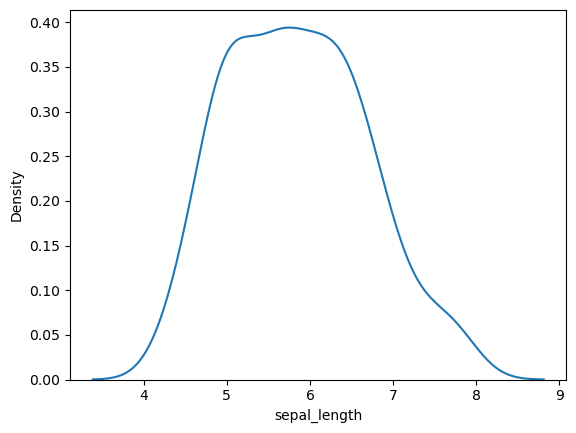

In [43]:
# QQplot
sns.kdeplot(iris['sepal_length'])

In [45]:
temp = sorted(iris['sepal_length'].tolist())

In [47]:
y_quant = []

for i in range(1,101):
    y_quant.append(np.percentile(temp,i))

In [48]:
samples = np.random.normal(loc = 0, scale = 1, size = 1000)

In [49]:
x_quant = []
for i in range(1,101):
    x_quant.append(np.percentile(samples, i))

<Axes: >

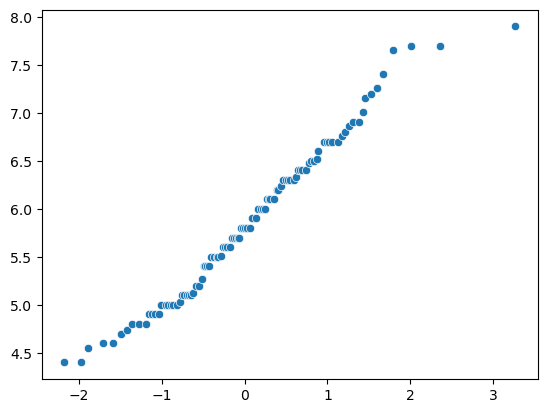

In [50]:
sns.scatterplot(x = x_quant, y = y_quant)

In [51]:
# log -log plot

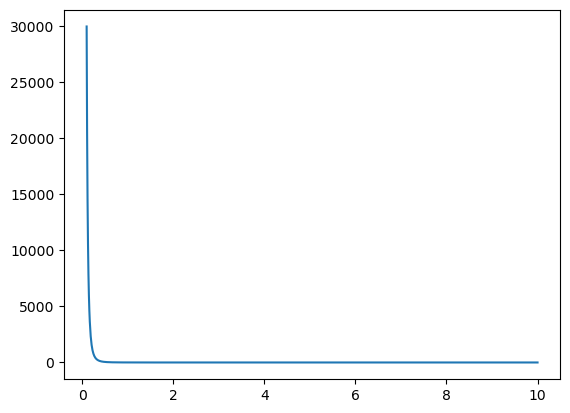

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters of the Pareto distribution
alpha = 3
xm = 1

# Create an array of x values
x = np.linspace(0.1, 10, 1000)

# Calculate the y values of the Pareto distribution
y = alpha * (xm**alpha) / (x**(alpha+1))


plt.plot(x,y)

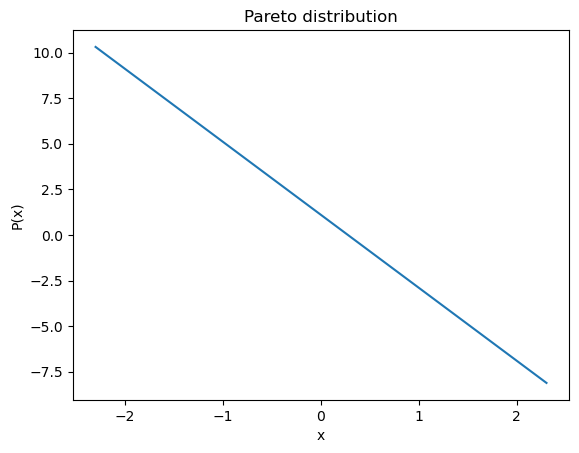

In [53]:
# Create the log-log plot
plt.plot(np.log(x),np.log(y))

# Add labels and a title
plt.xlabel('x')
plt.ylabel('P(x)')
plt.title('Pareto distribution')

# Show the plot
plt.show()